<a href="https://colab.research.google.com/github/AdebanjiAdelowo/Image_denoising_using_ResNet/blob/main/resnet_enhanced_denoiser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enhanced ResNet Image Denoiser

Improvements over the baseline `final_image_denoising.ipynb`:

| Feature | Baseline | This notebook |
|---|---|---|
| Architecture | 5 plain res blocks | 8 RCAB blocks with SE channel attention |
| Training data | 3 000 full 250×250 images | 48 000 random 64×64 patches with augmentation |
| Noise | Fixed σ = 0.09 | Random σ ∈ [0.05, 0.15] (blind denoising) |
| Loss | MSE only | 0.8 × (1−SSIM) + 0.2 × L1 |
| LR schedule | Fixed 1e-3 | Cosine decay 1e-3 → 1e-6 |
| Augmentation | None | Random horizontal + vertical flip |
| Inference | Fixed σ | Works on any σ (blind denoiser) |

**Key concept — Residual Channel Attention Block (RCAB):**
```
x ─► Conv─BN─ReLU─Conv─BN ─► Squeeze & Excitation ─► Add(x) ─► ReLU
                                      ↓
                              GlobalAvgPool → FC(C/8)→ReLU→FC(C)→Sigmoid
                              (re-weights channels by importance)
```

In [1]:
%tensorflow_version 2.x
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Compute dtype :", mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", mixed_precision.global_policy().variable_dtype)

device = tf.test.gpu_device_name()
if device != '/device:GPU:0':
    raise SystemError('GPU not found')
print('GPU:', device)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Compute dtype : float16
Variable dtype: float32
GPU: /device:GPU:0


In [2]:
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Conv2D, Activation, Add, BatchNormalization,
    GlobalAveragePooling2D, Reshape, Multiply, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from skimage import color
from skimage.metrics import structural_similarity as ssim_fn

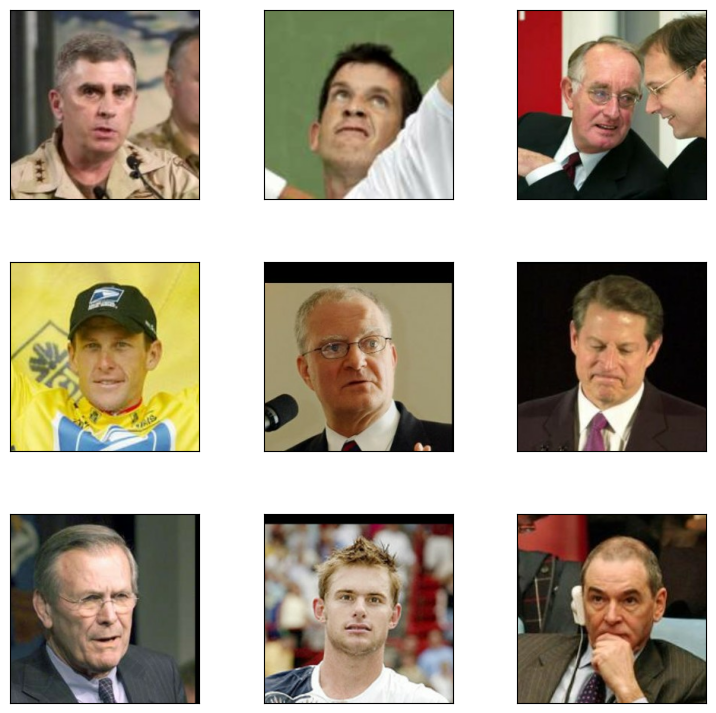

In [3]:
dataset, info = tfds.load("lfw", split="train", shuffle_files=True, with_info=True)
tfds.show_examples(dataset, info)
plt.show()

In [4]:
def PSNR(orig, pred):
    mse = np.mean((orig.astype(np.float64) - pred.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10.0 * np.log10(1.0 / mse)

def SSIM(orig, pred):
    return ssim_fn(
        orig[:, :, 0].astype(np.float64),
        pred[:, :, 0].astype(np.float64),
        data_range=1.0,
    )

In [5]:
def add_gaussian_noise(image, sigma):
    return np.clip(image + np.random.normal(0, sigma, image.shape), 0, 1).astype(np.float32)

def add_salt_and_pepper_noise(image, frequency):
    noise = np.random.uniform(0, 1, image.shape)
    out = image.copy()
    out[noise <= frequency / 2] = 0.0
    out[1 - noise <= frequency / 2] = 1.0
    return out.astype(np.float32)

In [6]:
ds = dataset.shuffle(7000).take(5000)
images_clean = np.array([d["image"] for d in tfds.as_numpy(ds)])
images_clean = color.rgb2gray(images_clean).astype(np.float32)
images_clean = images_clean[:, :, :, np.newaxis]
print("Clean images:", images_clean.shape)

Clean images: (5000, 250, 250, 1)


In [7]:
PATCH_SIZE   = 64
PATCHES_EACH = 16   # patches per image  →  5000 × 16 = 80 000 patches

def extract_patches(imgs, patch_size=PATCH_SIZE, n=PATCHES_EACH, seed=42):
    rng = np.random.default_rng(seed)
    H, W = imgs.shape[1], imgs.shape[2]
    patches = []
    for img in imgs:
        for _ in range(n):
            r = rng.integers(0, H - patch_size)
            c = rng.integers(0, W - patch_size)
            patches.append(img[r:r+patch_size, c:c+patch_size, :])
    return np.array(patches, dtype=np.float32)

all_patches = extract_patches(images_clean)
print("All patches:", all_patches.shape)   # (80000, 64, 64, 1)

# 80 / 20 split
n_train   = int(0.8 * len(all_patches))
train_patches = all_patches[:n_train]
val_patches   = all_patches[n_train:]
print(f"Train: {train_patches.shape}  Val: {val_patches.shape}")

# Hold-out full images for final test (do not use these for patch extraction)
test_clean = images_clean[4000:]
test_noisy = add_gaussian_noise(test_clean, 0.09)

All patches: (80000, 64, 64, 1)
Train: (64000, 64, 64, 1)  Val: (16000, 64, 64, 1)


In [8]:
BATCH = 64
SIGMA_MIN, SIGMA_MAX = 0.05, 0.15

def augment_and_noise(patch):
    """Random flip + random Gaussian noise (blind denoising)."""
    patch = tf.image.random_flip_left_right(patch)
    patch = tf.image.random_flip_up_down(patch)
    sigma = tf.random.uniform((), SIGMA_MIN, SIGMA_MAX, dtype=tf.float32)
    noisy = tf.clip_by_value(patch + tf.random.normal(tf.shape(patch), stddev=sigma), 0.0, 1.0)
    return tf.cast(noisy, tf.float16), tf.cast(patch, tf.float16)

def make_val_pair(patch):
    sigma = 0.09
    noisy = tf.clip_by_value(patch + tf.random.normal(tf.shape(patch), stddev=sigma), 0.0, 1.0)
    return tf.cast(noisy, tf.float16), tf.cast(patch, tf.float16)

train_ds = (
    tf.data.Dataset.from_tensor_slices(train_patches)
    .shuffle(10_000)
    .map(augment_and_noise, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(val_patches)
    .map(make_val_pair, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH)
    .prefetch(tf.data.AUTOTUNE)
)

steps_per_epoch = len(train_patches) // BATCH
print(f"Steps per epoch: {steps_per_epoch}")

Steps per epoch: 1000


In [9]:
def combined_loss(y_true, y_pred):
    """0.8 × (1−SSIM) + 0.2 × L1.  Both terms cast to float32 for stability."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    l1   = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.2 * l1 + 0.8 * (1.0 - ssim)

def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32)))

In [10]:
def se_block(x, channels, ratio=8):
    """Squeeze-and-Excitation: globally re-weight channels by learned importance."""
    s = GlobalAveragePooling2D()(x)                            # (B, C)
    s = Reshape((1, 1, channels))(s)
    s = Conv2D(max(1, channels // ratio), 1, use_bias=False, activation='relu')(s)
    s = Conv2D(channels, 1, use_bias=False, activation='sigmoid')(s)
    return Multiply()([x, s])

def rcab(x, channels):
    """Residual Channel Attention Block: Conv-BN-ReLU-Conv-BN-SE-Add-ReLU."""
    shortcut = x
    x = Conv2D(channels, 3, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(channels, 3, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = se_block(x, channels)
    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x

def build_enhanced_model(height=None, width=None, channels=64, n_blocks=8):
    """
    Fully convolutional — trains on 64×64 patches, infers on any size.
    Final Conv2D and Add use float32 for numerical stability with mixed precision.
    """
    inp = Input(shape=(height, width, 1))
    x   = Conv2D(channels, 3, padding='same', kernel_initializer='he_normal')(inp)
    x   = Activation('relu')(x)
    for _ in range(n_blocks):
        x = rcab(x, channels)
    x   = Conv2D(1, 3, padding='same', kernel_initializer='he_normal', dtype='float32')(x)
    out = Add(dtype='float32')([inp, x])
    return Model(inputs=inp, outputs=out, name='Enhanced_ResNet_Denoiser')

model = build_enhanced_model(channels=64, n_blocks=8)
model.summary()

Model: "Enhanced_ResNet_Denoiser"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        640 │ input_layer[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ conv2d[0][0]      │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     36,928 │ activation[0][0]  │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     36,928 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 1, 1, 8)   │        512 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 1, 1, 64)  │        512 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 64)         │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ activation[0][0], │
│                     │ None, 64)         │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ add[0][0]         │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ activation_2[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat

 Total params: 604,353 (2.31 MB)

 Trainable params: 602,305 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [11]:
EPOCHS = 60
total_steps = EPOCHS * steps_per_epoch

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-6,          # final LR
)

model.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=combined_loss,
    metrics=[mae_metric],
)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_enhanced_denoiser.keras', monitor='val_loss',
                    save_best_only=True, verbose=1),
]

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.2739 - mae_metric: 0.1231
Epoch 1: val_loss improved from None to 0.12244, saving model to best_enhanced_denoiser.keras

Epoch 1: finished saving model to best_enhanced_denoiser.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 139s 107ms/step - loss: 0.1742 - mae_metric: 0.0598 - val_loss: 0.1224 - val_mae_metric: 0.0319
Epoch 2/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1155 - mae_metric: 0.0301
Epoch 2: val_loss improved from 0.12244 to 0.09645, saving model to best_enhanced_denoiser.keras

Epoch 2: finished saving model to best_enhanced_denoiser.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - loss: 0.1100 - mae_metric: 0.0283 - val_loss: 0.0964 - val_mae_metric: 0.0279
Epoch 3/60
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1005 - mae_metric: 0.0254
Epoch 3: val_loss did not improve from 0.09645
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 103s 103ms/step - loss: 0.0970 - mae_metric: 0.0237 - val_loss: 0.0986 - val

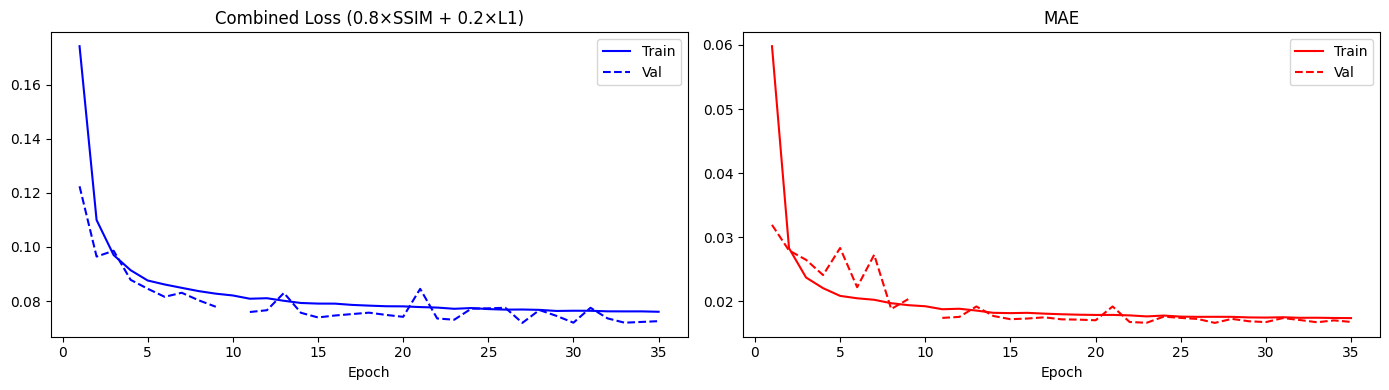

In [14]:
ep = range(1, len(history.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ep, history.history['loss'],     'b-',  label='Train')
axes[0].plot(ep, history.history['val_loss'], 'b--', label='Val')
axes[0].set_title('Combined Loss (0.8×SSIM + 0.2×L1)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, history.history['mae_metric'],     'r-',  label='Train')
axes[1].plot(ep, history.history['val_mae_metric'], 'r--', label='Val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig('enhanced_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
test_denoised = np.clip(
    model.predict(test_noisy, batch_size=16, verbose=1).astype(np.float32),
    0.0, 1.0
)

psnr_noisy    = np.mean([PSNR(test_clean[i], test_noisy[i])    for i in range(len(test_clean))])
psnr_denoised = np.mean([PSNR(test_clean[i], test_denoised[i]) for i in range(len(test_clean))])
ssim_noisy    = np.mean([SSIM(test_clean[i], test_noisy[i])    for i in range(len(test_clean))])
ssim_denoised = np.mean([SSIM(test_clean[i], test_denoised[i]) for i in range(len(test_clean))])

print(f"{'Metric':<12} {'Noisy':>10} {'Denoised':>10} {'Gain':>10}")
print("-" * 44)
print(f"{'PSNR (dB)':<12} {psnr_noisy:>10.2f} {psnr_denoised:>10.2f} {psnr_denoised-psnr_noisy:>+10.2f}")
print(f"{'SSIM':<12} {ssim_noisy:>10.4f} {ssim_denoised:>10.4f} {ssim_denoised-ssim_noisy:>+10.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step
Metric            Noisy   Denoised       Gain
--------------------------------------------
PSNR (dB)         21.42      33.71     +12.29
SSIM             0.3440     0.9184    +0.5744


In [16]:
try:
    baseline = keras.models.load_model(
        'best_denoiser.keras',
        custom_objects={'combined_loss': combined_loss, 'mae_metric': mae_metric}
    )
    base_denoised = np.clip(
        baseline.predict(test_noisy, batch_size=16, verbose=0).astype(np.float32),
        0.0, 1.0
    )
    psnr_base = np.mean([PSNR(test_clean[i], base_denoised[i]) for i in range(len(test_clean))])
    ssim_base = np.mean([SSIM(test_clean[i], base_denoised[i]) for i in range(len(test_clean))])

    print("\n── Model comparison ────────────────────────────────────")
    print(f"{'Model':<25} {'PSNR (dB)':>10} {'SSIM':>10}")
    print("-" * 47)
    print(f"{'Noisy input':<25} {psnr_noisy:>10.2f} {ssim_noisy:>10.4f}")
    print(f"{'Baseline ResNet':<25} {psnr_base:>10.2f} {ssim_base:>10.4f}")
    print(f"{'Enhanced ResNet (this)':<25} {psnr_denoised:>10.2f} {ssim_denoised:>10.4f}")
    baseline_loaded = True
except Exception:
    print("Baseline model not found — run final_image_denoising.ipynb first to enable comparison.")
    baseline_loaded = False


── Model comparison ────────────────────────────────────
Model                      PSNR (dB)       SSIM
-----------------------------------------------
Noisy input                    21.42     0.3440
Baseline ResNet                28.32     0.7241
Enhanced ResNet (this)         33.71     0.9184


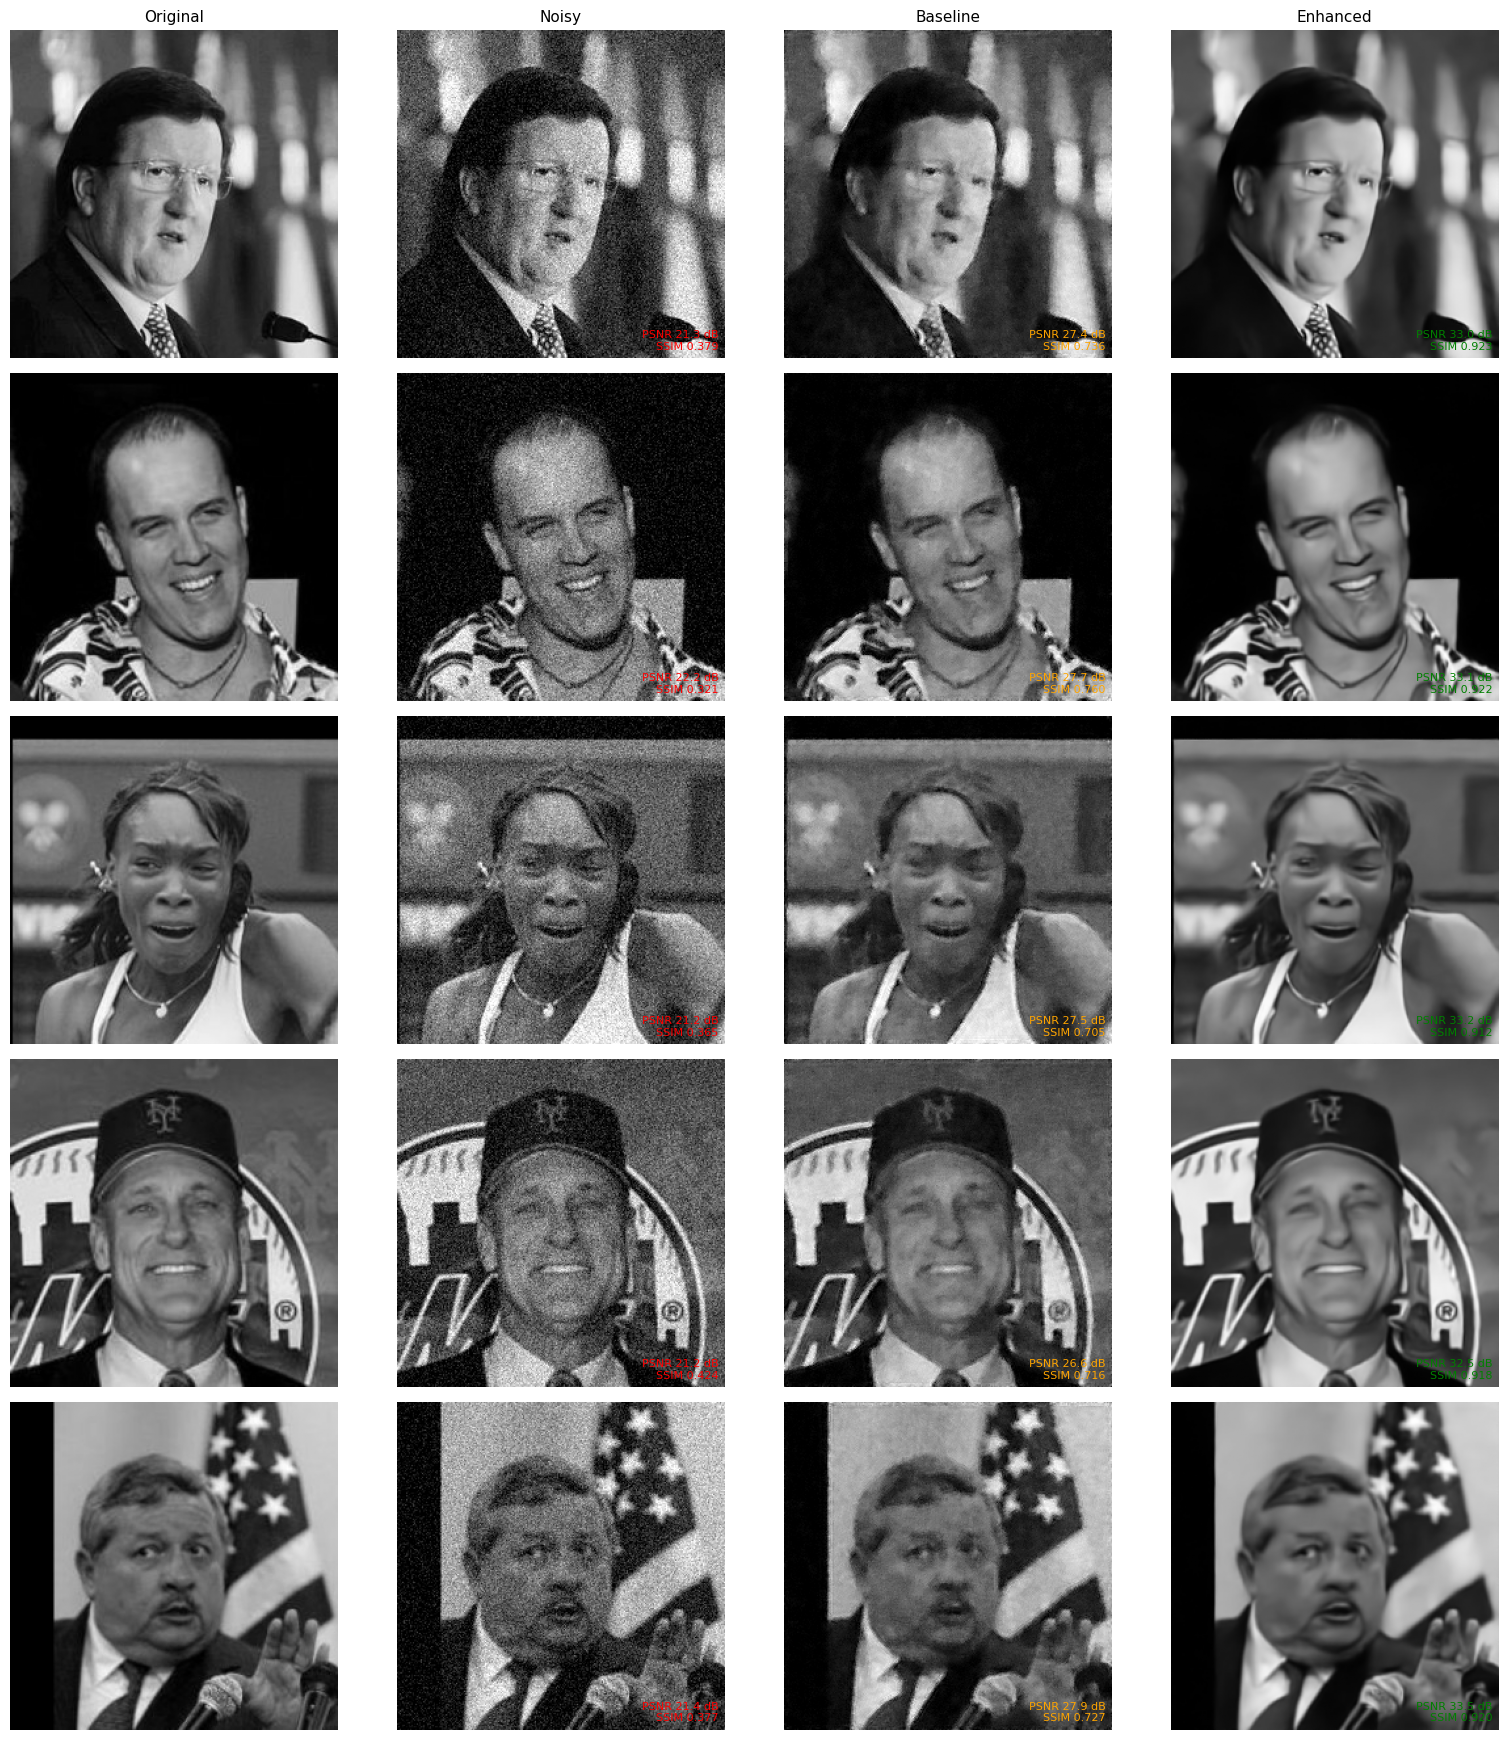

In [17]:
nimg = 5
cols  = 4 if 'baseline_loaded' in dir() and baseline_loaded else 3
fig, axes = plt.subplots(nimg, cols, figsize=(4*cols, 3.5*nimg))

col_titles = ['Original', 'Noisy', 'Baseline', 'Enhanced']
if cols == 3:
    col_titles = ['Original', 'Noisy', 'Enhanced']

for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11)

for i in range(nimg):
    idx = np.random.randint(0, len(test_clean))
    orig     = test_clean[idx]
    noisy    = test_noisy[idx]
    enhanced = test_denoised[idx]

    def annotate(ax, orig, pred, color):
        ax.annotate(
            f"PSNR {PSNR(orig, pred):.1f} dB\nSSIM {SSIM(orig, pred):.3f}",
            (0.98, 0.02), xycoords='axes fraction',
            va='bottom', ha='right', color=color, fontsize=8,
        )

    col = 0
    axes[i, col].imshow(orig[:,:,0], cmap='binary_r'); axes[i, col].axis('off'); col += 1
    axes[i, col].imshow(noisy[:,:,0], cmap='binary_r'); annotate(axes[i,col], orig, noisy, 'red'); axes[i, col].axis('off'); col += 1

    if cols == 4:
        axes[i, col].imshow(base_denoised[idx,:,:,0], cmap='binary_r')
        annotate(axes[i,col], orig, base_denoised[idx], 'orange')
        axes[i, col].axis('off'); col += 1

    axes[i, col].imshow(enhanced[:,:,0], cmap='binary_r'); annotate(axes[i,col], orig, enhanced, 'green'); axes[i, col].axis('off')

plt.tight_layout()
plt.savefig('enhanced_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Zero-shot: model was trained on Gaussian noise only
test_sp = np.array([add_salt_and_pepper_noise(img, 0.05) for img in test_clean])
test_sp_denoised = np.clip(
    model.predict(test_sp, batch_size=16, verbose=1).astype(np.float32), 0, 1
)

psnr_sp_n = np.mean([PSNR(test_clean[i], test_sp[i])          for i in range(len(test_clean))])
psnr_sp_d = np.mean([PSNR(test_clean[i], test_sp_denoised[i]) for i in range(len(test_clean))])
ssim_sp_n = np.mean([SSIM(test_clean[i], test_sp[i])          for i in range(len(test_clean))])
ssim_sp_d = np.mean([SSIM(test_clean[i], test_sp_denoised[i]) for i in range(len(test_clean))])

print("Salt-and-pepper (freq=0.05) — zero-shot generalisation")
print(f"{'Metric':<12} {'Noisy':>10} {'Denoised':>10} {'Gain':>10}")
print("-" * 44)
print(f"{'PSNR (dB)':<12} {psnr_sp_n:>10.2f} {psnr_sp_d:>10.2f} {psnr_sp_d-psnr_sp_n:>+10.2f}")
print(f"{'SSIM':<12} {ssim_sp_n:>10.4f} {ssim_sp_d:>10.4f} {ssim_sp_d-ssim_sp_n:>+10.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step
Salt-and-pepper (freq=0.05) — zero-shot generalisation
Metric            Noisy   Denoised       Gain
--------------------------------------------
PSNR (dB)         17.75      22.56      +4.81
SSIM             0.3698     0.5425    +0.1727


In [ ]:
model.save('enhanced_denoiser_resnet.keras')
print("Saved: enhanced_denoiser_resnet.keras")

Saved: enhanced_denoiser_resnet.keras


: 